In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/pacificrm/skindiseasedataset/Readme.md
/kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease/test/Benign_tumors/dermatofibroma-103.jpeg
/kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease/test/Benign_tumors/calcifying-epithelioma-7.jpeg
/kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease/test/Benign_tumors/epidermal-cyst-147.jpeg
/kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease/test/Benign_tumors/dermatofibroma-117.jpeg
/kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease/test/Benign_tumors/porokeratosis-70.jpeg
/kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease/test/Benign_tumors/skin-tags-polyps-44.jpeg
/kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease/test/Benign_tumors/acquired-digital-fibrokeratoma-3.jpeg
/kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease/test/Benig

In [2]:
selected_classes = [
    "Acne",
    "Actinic_Keratosis",
    "Bullous",
    "DrugEruption",
    "Eczema",
    "Lichen",
    "Lupus",
    "Rosacea",
    "Seborrh_Keratoses",
    "SkinCancer",
    "Tinea",
    "Unknown_Normal",
    "Vasculitis",
    "Vitiligo",
    "Warts"
]

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array, save_img
import numpy as np

2026-05-18 01:25:54.454089: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779067554.620794      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779067554.674671      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779067555.058898      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779067555.058931      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779067555.058934      23 computation_placer.cc:177] computation placer alr

In [4]:
IMG_SIZE=384

BATCH_SIZE = 32

In [5]:
def count_images_in_dataset(dataset_path):
    print(f"\nDataset Path: {dataset_path}")
    print("-" * 40)
    
    for class_name in sorted(os.listdir(dataset_path)):
        class_path = os.path.join(dataset_path, class_name)
        
        if os.path.isdir(class_path):
            num_images = len([
                file for file in os.listdir(class_path)
                if file.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])
            
            print(f"{class_name}: {num_images} images")

count_images_in_dataset("/kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease/train")


Dataset Path: /kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease/train
----------------------------------------
Acne: 593 images
Actinic_Keratosis: 748 images
Benign_tumors: 1093 images
Bullous: 504 images
Candidiasis: 248 images
DrugEruption: 547 images
Eczema: 1010 images
Infestations_Bites: 524 images
Lichen: 553 images
Lupus: 311 images
Moles: 361 images
Psoriasis: 820 images
Rosacea: 254 images
Seborrh_Keratoses: 455 images
SkinCancer: 693 images
Sun_Sunlight_Damage: 312 images
Tinea: 923 images
Unknown_Normal: 1651 images
Vascular_Tumors: 543 images
Vasculitis: 461 images
Vitiligo: 714 images
Warts: 580 images


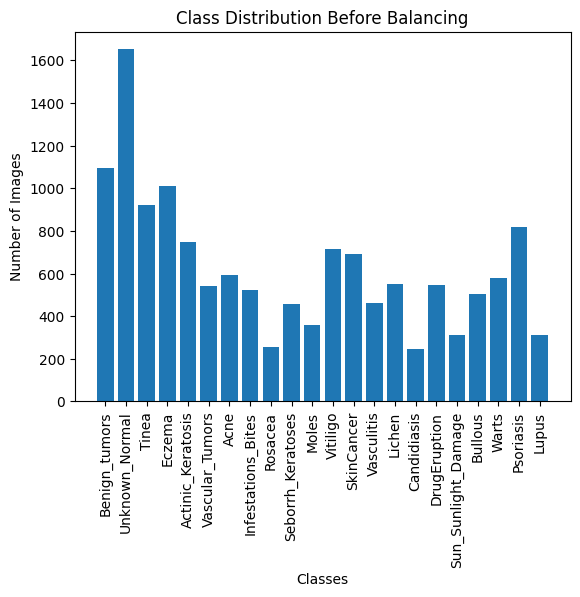

In [6]:
import matplotlib.pyplot as plt
train_path = "/kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease/train"  

class_counts = {}

for class_name in os.listdir(train_path):
    class_folder = os.path.join(train_path, class_name)
    if os.path.isdir(class_folder):
        class_counts[class_name] = len(os.listdir(class_folder))

plt.figure()
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("Class Distribution Before Balancing")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

In [7]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_names=selected_classes,
    label_mode="categorical"
)

Found 9997 files belonging to 15 classes.
Using 1999 files for validation.


I0000 00:00:1779067580.757923      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779067580.763831      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [8]:
TARGET_SIZE = 3000

In [9]:
import shutil
import random

SOURCE_TRAIN = "/kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease/train"
DEST_TRAIN = "/kaggle/working/balanced_train"

os.makedirs(DEST_TRAIN, exist_ok=True)

In [10]:
import os
import cv2
import random
import numpy as np
import shutil
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

In [11]:
def is_blurred(image_path: str, threshold: float = 20.0) -> bool:
    img = cv2.imread(image_path)

    if img is None:
        return True  # corrupted image

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    variance = cv2.Laplacian(gray, cv2.CV_64F).var()

    return variance < threshold

In [12]:
datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [13]:
for class_name in selected_classes:

    src_path = os.path.join(SOURCE_TRAIN, class_name)
    dst_path = os.path.join(DEST_TRAIN, class_name)

    if not os.path.exists(src_path):
        print(f"{class_name} not found in source")
        continue

    os.makedirs(dst_path, exist_ok=True)

    for img in os.listdir(src_path):
        shutil.copy(
            os.path.join(src_path, img),
            os.path.join(dst_path, img)
        )

print("Selected classes copied successfully.")

Selected classes copied successfully.


In [14]:
print("\nRemoving blurred images...\n")

total_deleted = 0

for class_name in selected_classes:

    class_path = os.path.join(DEST_TRAIN, class_name)

    if not os.path.exists(class_path):
        continue

    deleted = 0

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        if is_blurred(img_path, threshold=20.0):
            os.remove(img_path)
            deleted += 1

    total_deleted += deleted
    print(f"{class_name}: {deleted} blurred images deleted")

print(f"\nTotal deleted: {total_deleted} images")


Removing blurred images...

Acne: 3 blurred images deleted
Actinic_Keratosis: 5 blurred images deleted
Bullous: 2 blurred images deleted
DrugEruption: 3 blurred images deleted
Eczema: 0 blurred images deleted
Lichen: 1 blurred images deleted
Lupus: 2 blurred images deleted
Rosacea: 0 blurred images deleted
Seborrh_Keratoses: 0 blurred images deleted
SkinCancer: 0 blurred images deleted
Tinea: 0 blurred images deleted
Unknown_Normal: 264 blurred images deleted
Vasculitis: 0 blurred images deleted
Vitiligo: 6 blurred images deleted
Warts: 0 blurred images deleted

Total deleted: 286 images


In [15]:
print("\nAugmenting dataset...\n")

for class_name in selected_classes:

    class_path = os.path.join(DEST_TRAIN, class_name)

    if not os.path.exists(class_path):
        continue

    clean_images = os.listdir(class_path)
    current_size = len(clean_images)

    if current_size == 0:
        print(f"{class_name} has no images!")
        continue

    if current_size >= TARGET_SIZE:
        print(f"{class_name}: already enough ({current_size})")
        continue

    print(f"{class_name}: {current_size} -> {TARGET_SIZE}")

    while current_size < TARGET_SIZE:

        img_name = random.choice(clean_images)
        img_path = os.path.join(class_path, img_name)

        try:
            img = load_img(img_path)
            x = img_to_array(img)
            x = np.expand_dims(x, axis=0)

            aug_iter = datagen.flow(x, batch_size=1)
            aug_img = next(aug_iter)[0]

            # ✔️ important fix: scale properly
            aug_img = np.clip(aug_img, 0, 255).astype(np.uint8)

            new_name = f"aug_{current_size}_{img_name}"

            save_img(
                os.path.join(class_path, new_name),
                aug_img
            )

            current_size += 1

        except Exception as e:
            print(f"Error with {img_path}: {e}")

print("\nDone! Clean augmented dataset is ready.")


Augmenting dataset...

Acne: 590 -> 3000
Actinic_Keratosis: 743 -> 3000
Bullous: 502 -> 3000
DrugEruption: 544 -> 3000
Eczema: 1010 -> 3000
Lichen: 552 -> 3000
Lupus: 309 -> 3000
Rosacea: 254 -> 3000
Seborrh_Keratoses: 455 -> 3000
SkinCancer: 693 -> 3000
Tinea: 923 -> 3000
Unknown_Normal: 1387 -> 3000
Vasculitis: 461 -> 3000
Vitiligo: 708 -> 3000
Warts: 580 -> 3000

Done! Clean augmented dataset is ready.


In [16]:
count_images_in_dataset("/kaggle/working/balanced_train")


Dataset Path: /kaggle/working/balanced_train
----------------------------------------
Acne: 3000 images
Actinic_Keratosis: 3000 images
Bullous: 3000 images
DrugEruption: 3000 images
Eczema: 3000 images
Lichen: 3000 images
Lupus: 3000 images
Rosacea: 3000 images
Seborrh_Keratoses: 3000 images
SkinCancer: 3000 images
Tinea: 3000 images
Unknown_Normal: 3000 images
Vasculitis: 3000 images
Vitiligo: 3000 images
Warts: 3000 images


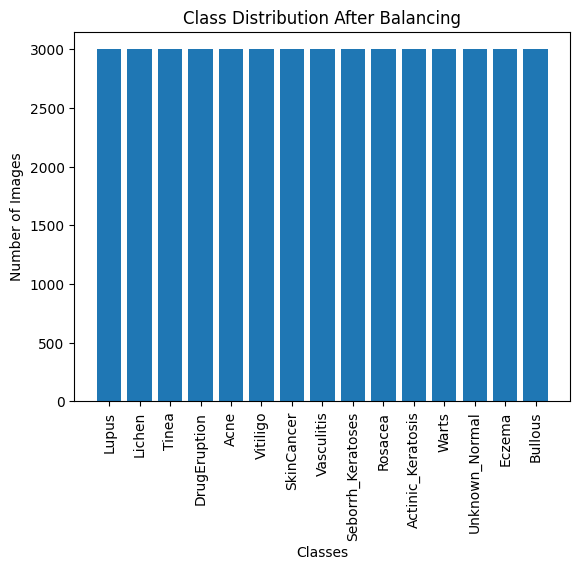

In [17]:
train_path = "/kaggle/working/balanced_train"  

class_counts = {}

for class_name in os.listdir(train_path):
    class_folder = os.path.join(train_path, class_name)
    if os.path.isdir(class_folder):
        class_counts[class_name] = len(os.listdir(class_folder))

plt.figure()
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("Class Distribution After Balancing")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

In [18]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,          # 20% validation
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 45000 files belonging to 15 classes.
Using 36000 files for training.


In [19]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease/test",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    class_names=selected_classes,
    shuffle=False
)

Found 1116 files belonging to 15 classes.


In [20]:
class_names = train_ds.class_names
NUM_CLASSES = len(train_ds.class_names) 

In [21]:
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.optimizers import Adam

INITIAL_LR = 1e-3

In [22]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [23]:
base_model = EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [24]:
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs)

In [25]:
model.compile(
    optimizer=Adam(learning_rate=INITIAL_LR),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
        ]
)

In [26]:
es = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
rlp = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

In [27]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,       
    callbacks=[es,rlp]
)

Epoch 1/25


E0000 00:00:1779070468.942569      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetv2-s_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1779070472.391922      81 cuda_dnn.cc:529] Loaded cuDNN version 91002


1125/1125 ━━━━━━━━━━━━━━━━━━━━ 581s 495ms/step - accuracy: 0.3879 - loss: 1.9071 - precision: 0.7252 - recall: 0.1358 - val_accuracy: 0.5948 - val_loss: 1.2951 - val_precision: 0.8389 - val_recall: 0.3492 - learning_rate: 0.0010
Epoch 2/25
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 549s 488ms/step - accuracy: 0.5407 - loss: 1.4207 - precision: 0.7606 - recall: 0.3333 - val_accuracy: 0.6398 - val_loss: 1.1533 - val_precision: 0.8556 - val_recall: 0.4267 - learning_rate: 0.0010
Epoch 3/25
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 550s 489ms/step - accuracy: 0.5548 - loss: 1.3547 - precision: 0.7524 - recall: 0.3721 - val_accuracy: 0.6523 - val_loss: 1.1015 - val_precision: 0.8597 - val_recall: 0.4537 - learning_rate: 0.0010
Epoch 4/25
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 550s 489ms/step - accuracy: 0.5649 - loss: 1.3268 - precision: 0.7539 - recall: 0.3910 - val_accuracy: 0.6573 - val_loss: 1.0628 - val_precision: 0.8502 - val_recall: 0.4827 - learning_rate: 0.0010
Epoch 5/25
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 550s 488m

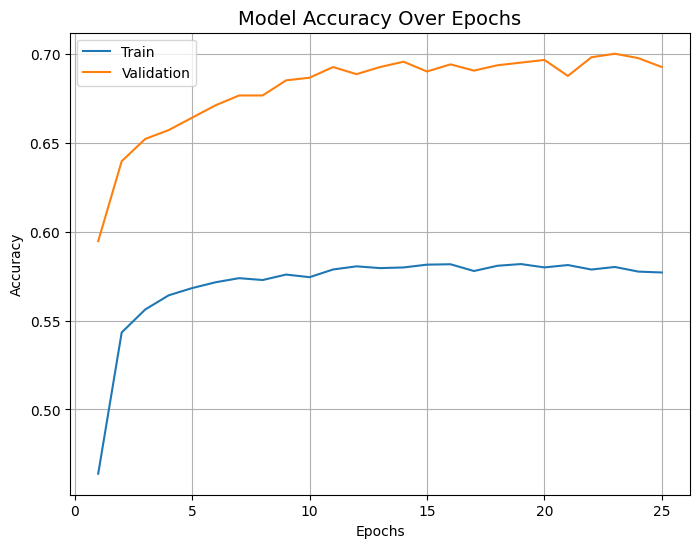

In [28]:
epochs = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(8,6))
plt.plot(epochs, history.history['accuracy'])
plt.plot(epochs, history.history['val_accuracy'])

plt.title("Model Accuracy Over Epochs", fontsize=14)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.grid(True)

plt.show()

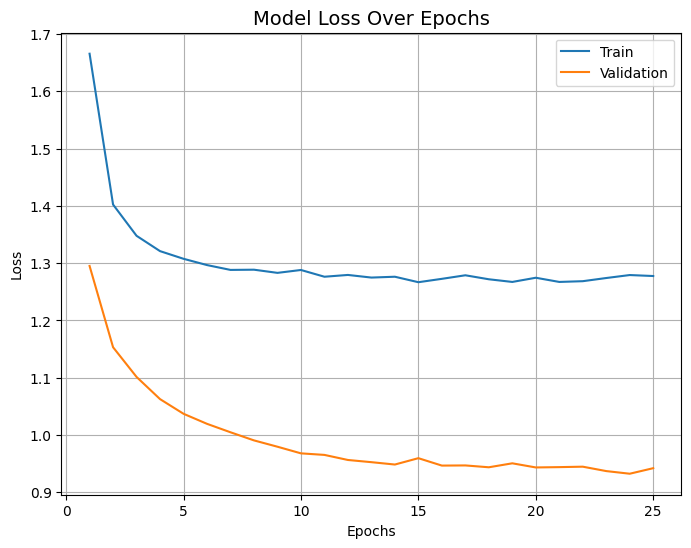

In [29]:
plt.figure(figsize=(8,6))
plt.plot(epochs, history.history['loss'])
plt.plot(epochs, history.history['val_loss'])

plt.title("Model Loss Over Epochs", fontsize=14)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.grid(True)

plt.show()

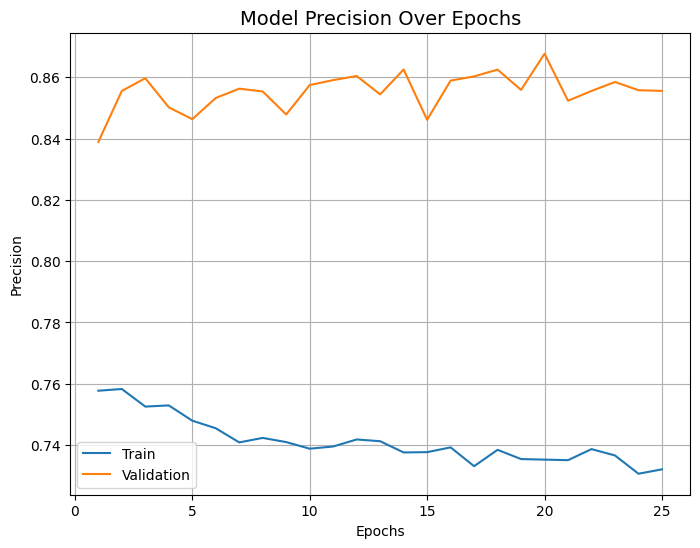

In [30]:
plt.figure(figsize=(8,6))
plt.plot(epochs, history.history['precision'])
plt.plot(epochs, history.history['val_precision'])

plt.title("Model Precision Over Epochs", fontsize=14)
plt.xlabel("Epochs")
plt.ylabel("Precision")
plt.legend(["Train", "Validation"])
plt.grid(True)

plt.show()

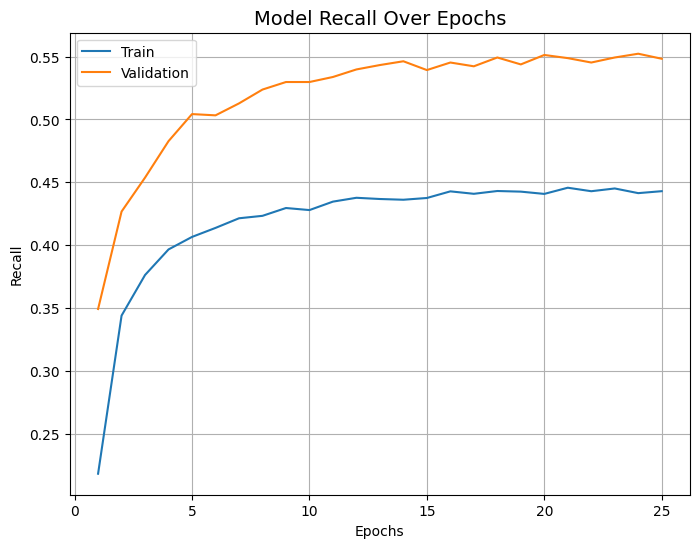

In [31]:
plt.figure(figsize=(8,6))
plt.plot(epochs, history.history['recall'])
plt.plot(epochs, history.history['val_recall'])

plt.title("Model Recall Over Epochs", fontsize=14)
plt.xlabel("Epochs")
plt.ylabel("Recall")
plt.legend(["Train", "Validation"])
plt.grid(True)

plt.show()

In [32]:
base_model.trainable = True

In [33]:
len(base_model.layers) 

513

In [34]:
for layer in base_model.layers[:-100]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=INITIAL_LR/10), 
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
        ]
)

In [35]:
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[es,rlp]
)

Epoch 1/30


E0000 00:00:1779084274.685036      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetv2-s_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1125/1125 ━━━━━━━━━━━━━━━━━━━━ 744s 631ms/step - accuracy: 0.5824 - loss: 1.3450 - precision: 0.6980 - recall: 0.4696 - val_accuracy: 0.8504 - val_loss: 0.4574 - val_precision: 0.9044 - val_recall: 0.7999 - learning_rate: 1.0000e-04
Epoch 2/30
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 704s 626ms/step - accuracy: 0.7932 - loss: 0.6288 - precision: 0.8656 - recall: 0.7246 - val_accuracy: 0.9180 - val_loss: 0.2392 - val_precision: 0.9382 - val_recall: 0.9035 - learning_rate: 1.0000e-04
Epoch 3/30
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 704s 626ms/step - accuracy: 0.8771 - loss: 0.3762 - precision: 0.9143 - recall: 0.8466 - val_accuracy: 0.9535 - val_loss: 0.1428 - val_precision: 0.9624 - val_recall: 0.9470 - learning_rate: 1.0000e-04
Epoch 4/30
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 704s 626ms/step - accuracy: 0.9162 - loss: 0.2492 - precision: 0.9389 - recall: 0.8995 - val_accuracy: 0.9705 - val_loss: 0.0967 - val_precision: 0.9753 - val_recall: 0.9665 - learning_rate: 1.0000e-04
Epoch 5/30
1125/1125 ━━━━━━━━━━━━━━

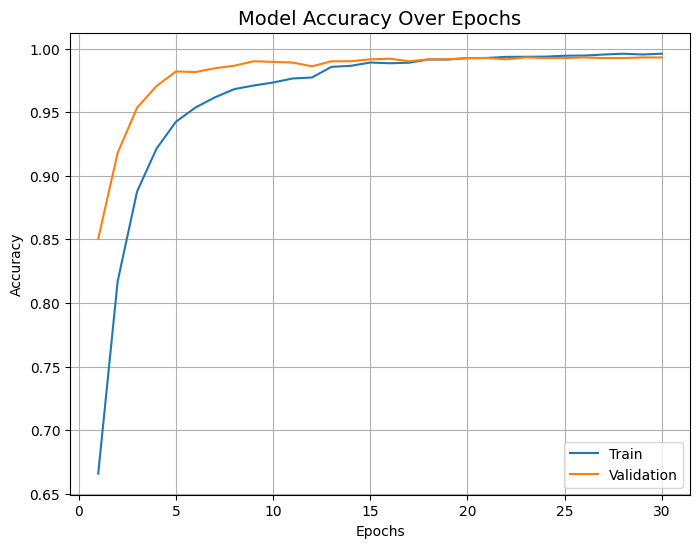

In [36]:
epochs = range(1, len(history_finetune.history['accuracy']) + 1)

plt.figure(figsize=(8,6))
plt.plot(epochs, history_finetune.history['accuracy'])
plt.plot(epochs, history_finetune.history['val_accuracy'])

plt.title("Model Accuracy Over Epochs", fontsize=14)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.grid(True)

plt.show()

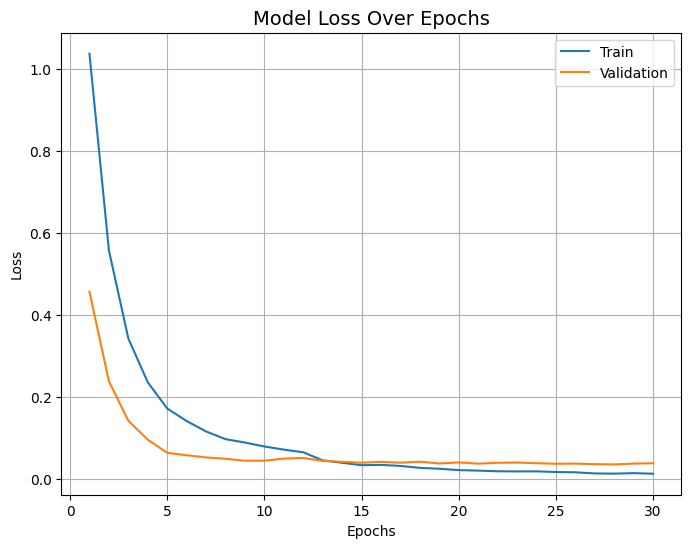

In [37]:
plt.figure(figsize=(8,6))
plt.plot(epochs, history_finetune.history['loss'])
plt.plot(epochs, history_finetune.history['val_loss'])

plt.title("Model Loss Over Epochs", fontsize=14)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.grid(True)

plt.show()

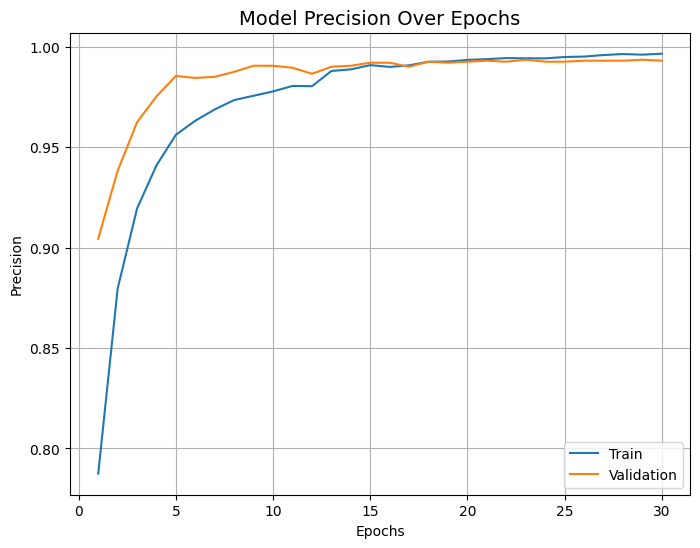

In [38]:
plt.figure(figsize=(8,6))
plt.plot(epochs, history_finetune.history['precision'])
plt.plot(epochs, history_finetune.history['val_precision'])

plt.title("Model Precision Over Epochs", fontsize=14)
plt.xlabel("Epochs")
plt.ylabel("Precision")
plt.legend(["Train", "Validation"])
plt.grid(True)

plt.show()

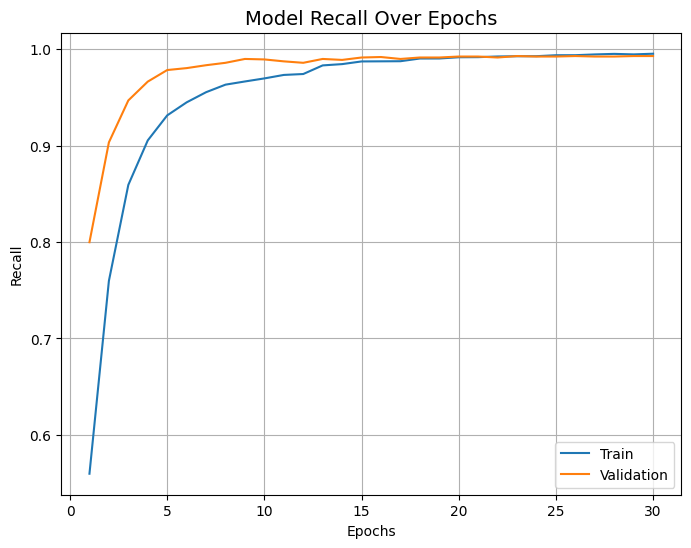

In [39]:
plt.figure(figsize=(8,6))
plt.plot(epochs, history_finetune.history['recall'])
plt.plot(epochs, history_finetune.history['val_recall'])

plt.title("Model Recall Over Epochs", fontsize=14)
plt.xlabel("Epochs")
plt.ylabel("Recall")
plt.legend(["Train", "Validation"])
plt.grid(True)

plt.show()

In [40]:
results = model.evaluate(test_ds)

for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 16s 464ms/step - accuracy: 0.8392 - loss: 0.9945 - precision: 0.8529 - recall: 0.8369
loss: 0.9001
compile_metrics: 0.8539


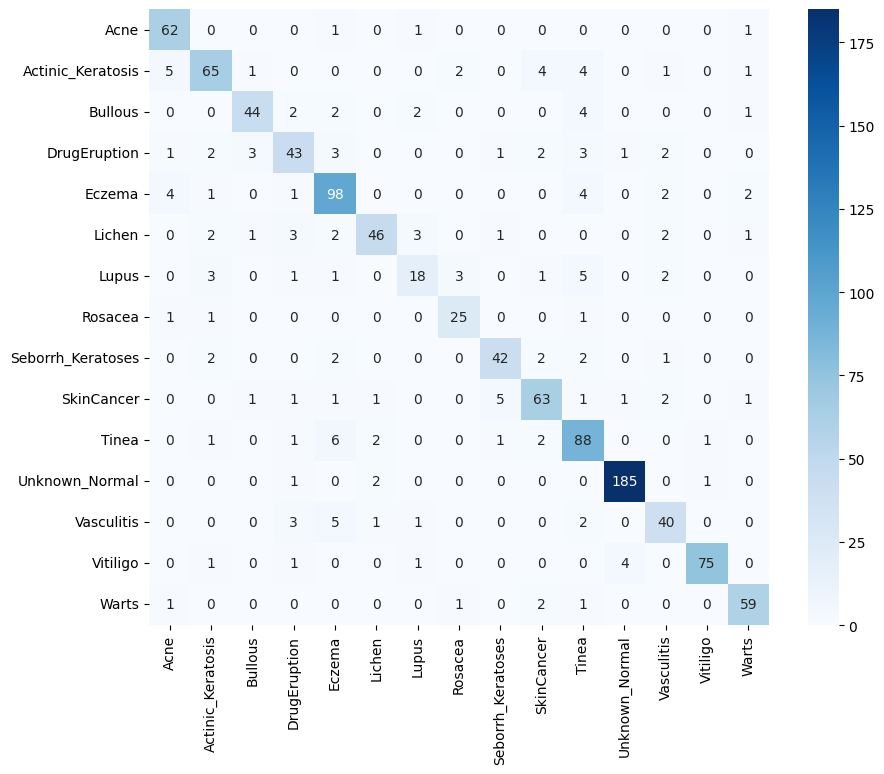

In [41]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

for x, y in test_ds:
    preds = model.predict(x, verbose=0)
    y_true.extend(np.argmax(y.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.show()

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

                   precision    recall  f1-score   support

             Acne       0.84      0.95      0.89        65
Actinic_Keratosis       0.83      0.78      0.81        83
          Bullous       0.88      0.80      0.84        55
     DrugEruption       0.75      0.70      0.73        61
           Eczema       0.81      0.88      0.84       112
           Lichen       0.88      0.75      0.81        61
            Lupus       0.69      0.53      0.60        34
          Rosacea       0.81      0.89      0.85        28
Seborrh_Keratoses       0.84      0.82      0.83        51
       SkinCancer       0.83      0.82      0.82        77
            Tinea       0.77      0.86      0.81       102
   Unknown_Normal       0.97      0.98      0.97       189
       Vasculitis       0.77      0.77      0.77        52
         Vitiligo       0.97      0.91      0.94        82
            Warts       0.89      0.92      0.91        64

         accuracy                           0.85      

In [43]:
model.save("/kaggle/working/my_model.keras")
import shutil

shutil.make_archive(
    base_name="/kaggle/working/my_model",  
    format="zip",
    root_dir="/kaggle/working",
    base_dir="my_model.keras"
)

'/kaggle/working/my_model.zip'